**# Importing Required Libraries for House Rent Prediction**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


**# Loading the Dataset**

In [2]:
df = pd.read_csv("../data/House_Rent_Dataset.csv")
print("Data load successfull")

Data load successfull


# Basic EDA (Exploratory Data Analysis): 
## Understanding Dataset Structure

**1.Displaying the First Five Rows of the Dataset**

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


**2.Check dataset information**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


**3. Checking Dataset Shape**

In [5]:
df.shape

(4746, 12)

**4. Statistical Summary of Numerical Features**

In [6]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


**5. Unique Value Analysis**

In [7]:
df.nunique()

Posted On              81
BHK                     6
Rent                  243
Size                  615
Floor                 480
Area Type               3
Area Locality        2235
City                    6
Furnishing Status       3
Tenant Preferred        3
Bathroom                8
Point of Contact        3
dtype: int64

**6. Correlation Analysis: Checking correlation between numerical features**

In [8]:
df.corr(numeric_only=True)

,BHK,Rent,Size,Bathroom
BHK,1.000000,0.369718,0.716145,0.794885
Rent,0.369718,1.000000,0.413551,0.441215
Size,0.716145,0.413551,1.000000,0.740703
Bathroom,0.794885,0.441215,0.740703,1.000000


**7. Distribution of Rent**

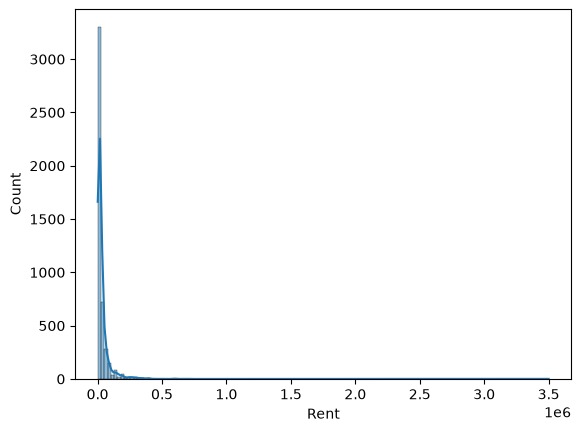

In [9]:
sns.histplot(df['Rent'], kde=True)
plt.show()

**8. Missing Value Check**

In [10]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

**9.Duplicate Check**

In [11]:
df.duplicated().sum()

np.int64(0)

**10.Outlier Detection**

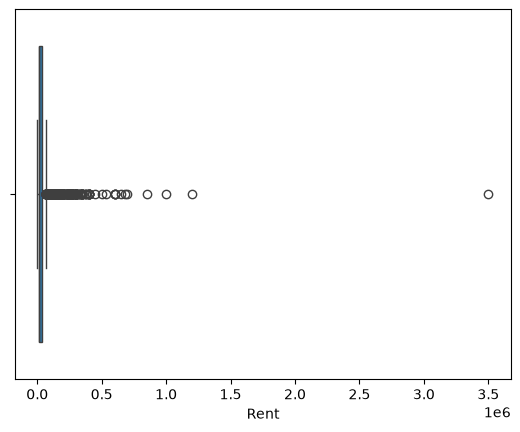

In [12]:
sns.boxplot(x=df['Rent'])
plt.show()

**11.Categorical Feature Analysis**

**Understanding how categories affect rent.**

**Examples:**

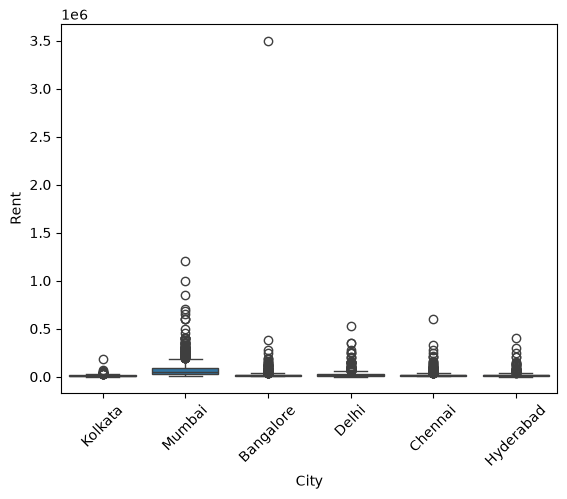

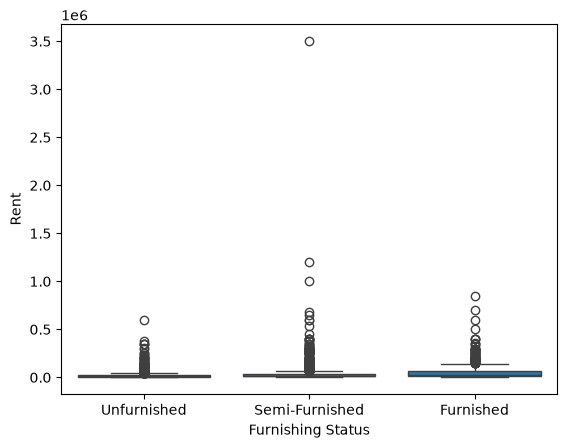

In [13]:
#City-wise rent:
sns.boxplot(x='City', y='Rent', data=df)
plt.xticks(rotation=45)
plt.show()
#Furnishing status:
sns.boxplot(x='Furnishing Status', y='Rent', data=df)
plt.show()


**12. Remaining small EDA checks:**

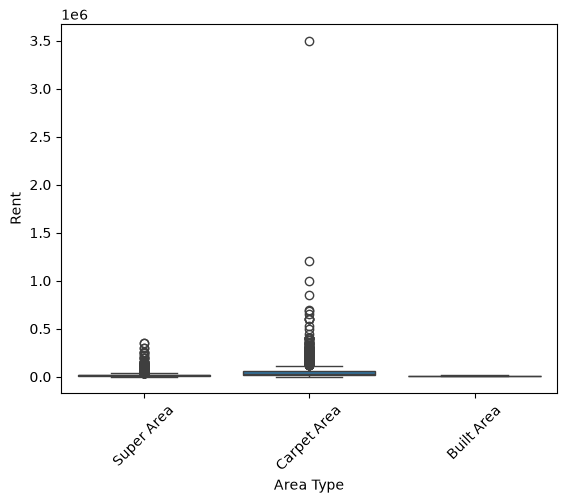

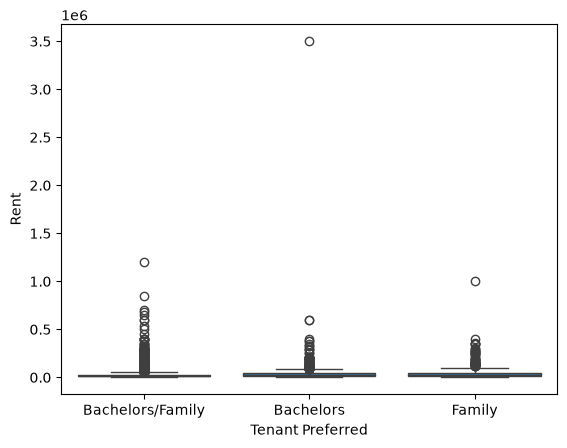

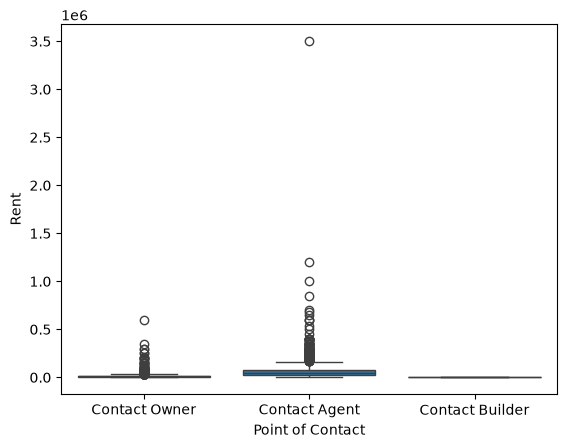

In [14]:
#1. Area Type vs Rent:
sns.boxplot(x='Area Type', y='Rent', data=df)
plt.xticks(rotation=45)
plt.show()

#2. Tenant Preferred vs Rent:
sns.boxplot(x='Tenant Preferred', y='Rent', data=df)
plt.show()

#3. Point of Contact vs Rent:
sns.boxplot(x='Point of Contact', y='Rent', data=df)
plt.show()

**#Phase 2: Data Cleaning & Feature Engineering** <br>
**##Objective**

The objective of this phase is to clean the dataset and transform the raw data into meaningful numerical features that can be used by Machine Learning algorithms.
<br>

Machine Learning models cannot directly understand text or dates. Therefore, we need to: <br>

Clean unnecessary data <br>
Convert dates into datetime format,<br>
Extract useful information from dates <br>
Transform categorical variables into numerical form <br>
Handle complex features such as the Floor column  <br>
Prepare the dataset for model training 

**Step 1: Convert Date Column into Datetime Format**

In [23]:
df['Posted On']=pd.to_datetime(df['Posted On'])
df['Posted On'].dtype

dtype('<M8[us]')

**Step 2: Extract Useful Date Features**<br>
Machine Learning algorithms cannot directly learn from a datetime object.<br>
Instead, we extract useful numerical features such as:<br>
Year<br>
Month<br>
Day<br>
These numerical values may contain useful patterns.

In [30]:
df['Year']=df['Posted On'].dt.year
df['Month']=df['Posted On'].dt.month
df['Day']=df['Posted On'].dt.day
df[['Posted On','Year','Month','Day']].head()

,Posted On,Year,Month,Day
0,2022-05-18,2022,5,18
1,2022-05-13,2022,5,13
2,2022-05-16,2022,5,16
3,2022-07-04,2022,7,4
4,2022-05-09,2022,5,9


**Step 3: Remove the Original Date Column**<br>
After extracting the useful information, the original date column is no longer required.<br>
Keeping unnecessary columns can sometimes reduce model performance.

In [31]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact', 'Year', 'Month', 'Day'],
      dtype='str')

In [ ]:
df.drop('Posted On',axis=1,inplace=True)

In [38]:
df.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact',
       'Year', 'Month', 'Day'],
      dtype='str')

**Step 4: Understanding the Floor Column**
<br>Before cleaning the Floor column, let's inspect it.

In [45]:
df['Floor'].unique()

<StringArray>
[ 'Ground out of 2',       '1 out of 3',       '1 out of 2',
  'Ground out of 1',  'Ground out of 4',       '1 out of 4',
       '1 out of 1',  'Ground out of 3',       '2 out of 3',
       '4 out of 5',
 ...
      '4 out of 26',     '24 out of 33',      '4 out of 17',
      '1 out of 35',     '11 out of 35', 'Ground out of 15',
 'Ground out of 27',     '15 out of 30',     '12 out of 30',
     '23 out of 34']
Length: 480, dtype: str

**Step 5: Split the Floor Column**
The Floor column actually contains two different pieces of information:<br>
-Current Floor.<br>
-Total Floors.<br>
For example,<br>
4 out of 10<br>
Means:<br>
Current Floor = 4<br>
Total Floors = 10<br>
Instead of keeping both values in one text column, we separate them into two numerical columns. This makes the information much more useful for machine learning.

In [56]:
df[['Current Floor','Total Floors']]=df['Floor'].str.split('out of',expand=True)
df[['Current Floor','Total Floors']].head()

,Current Floor,Total Floors
0,Ground,2
1,1,3
2,1,3
3,1,2
4,1,2


**Step 6: Check Unique Values of Current Floor<br>
Before converting the values into numbers, inspect all unique values.**

In [60]:
df['Current Floor'].unique()

<StringArray>
[        'Ground ',              '1 ',              '2 ',              '4 ',
              '3 ',              '5 ',              '7 ',              '8 ',
 'Upper Basement ',             '11 ', 'Lower Basement ',              '6 ',
             '14 ',             '43 ',             '13 ',             '18 ',
             '17 ',              '9 ',             '19 ',             '60 ',
             '34 ',             '12 ',             '26 ',             '25 ',
             '53 ',             '16 ',             '10 ',             '39 ',
             '32 ',             '47 ',             '28 ',             '20 ',
             '15 ',             '65 ',             '40 ',             '37 ',
             '22 ',             '21 ',             '30 ',             '35 ',
             '33 ',             '44 ',             '41 ',             '46 ',
             '27 ',             '45 ',             '48 ',             '50 ',
             '24 ',             '23 ',             '29 ',     

In [59]:
df['Total Floors'].head()

0     2
1     3
2     3
3     2
4     2
Name: Total Floors, dtype: str

**Step 7: Remove Extra Spaces**<br>
Many values contain unwanted spaces at the beginning or end. These spaces make '1 ' different from '1', even though they represent the same floor.

In [61]:
df['Current Floor'] = df['Current Floor'].str.strip()
df['Total Floors'] = df['Total Floors'].str.strip()

In [64]:
df['Current Floor'].unique()

<StringArray>
[        'Ground',              '1',              '2',              '4',
              '3',              '5',              '7',              '8',
 'Upper Basement',             '11', 'Lower Basement',              '6',
             '14',             '43',             '13',             '18',
             '17',              '9',             '19',             '60',
             '34',             '12',             '26',             '25',
             '53',             '16',             '10',             '39',
             '32',             '47',             '28',             '20',
             '15',             '65',             '40',             '37',
             '22',             '21',             '30',             '35',
             '33',             '44',             '41',             '46',
             '27',             '45',             '48',             '50',
             '24',             '23',             '29',             '49',
             '36',             '76']


** Step 8: Convert Special Floor Names to Numbers**
Machine Learning algorithms cannot understand text values like:<br>
Ground<br>
Upper Basement<br>
Lower Basement<br>
We replace them with numerical values:<br>
Original Value	New Value<br>
Ground	0<br>
Lower Basement	-1<br>
Upper Basement	-2<br>